In [15]:
import pandas as pd
import numpy as np

In [16]:
eda_S2 = pd.read_csv("S2_EDA.csv", header=None).values.flatten()
temp_S2 = pd.read_csv("S2_TEMP.csv", header=None).values.flatten()

eda_S3 = pd.read_csv("S3_EDA.csv", header=None).values.flatten()
temp_S3 = pd.read_csv("S3_TEMP.csv", header=None).values.flatten()

In [28]:
eda_threshold = np.percentile(eda, 70)
temp_threshold = np.percentile(temp, 70)

stress = 1 if (eda_mean > eda_threshold or temp_mean > temp_threshold) else 0

In [30]:
window_size = 1000
step = 1000

X, y = [], []

for i in range(0, len(eda) - window_size, step):
    eda_w = eda[i:i+window_size]
    temp_w = temp[i:i+window_size]

    eda_mean = np.mean(eda_w)
    eda_std = np.std(eda_w)

    temp_mean = np.mean(temp_w)
    temp_std = np.std(temp_w)

    # Simulated stress labeling, using globally defined thresholds from previous cell
    stress = 1 if (eda_mean > eda_threshold or temp_mean > temp_threshold) else 0

    X.append([eda_mean, eda_std, temp_mean, temp_std])
    y.append(stress)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (62, 4)


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9230769230769231


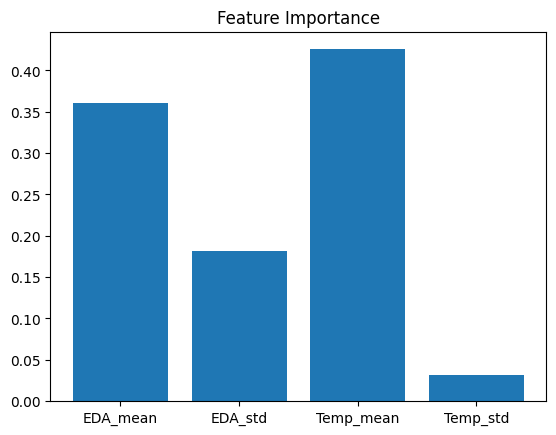

In [32]:
import matplotlib.pyplot as plt

features = ["EDA_mean", "EDA_std", "Temp_mean", "Temp_std"]
importances = model.feature_importances_

plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

In [33]:
import joblib
joblib.dump(model, "stress_model.pkl")

['stress_model.pkl']